In [1]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns 

In [2]:
df= pd.read_csv("diabetes_dirty_dataset.csv")
print(df.shape)
df.head()

(1015, 15)


,PatientID,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Cholesterol,SodiumLevel,HeartRate,VitaminD,ExerciseHrsPerWeek,Outcome
0,P0529,2,120,82,40.0,51.0,35.2,1.105,37.0,168,140.0,84,17.8,6.5,0
1,P0283,8,121,107,34.0,182.0,36.2,0.338,53.0,220,138.3,84,48.5,1.2,1
2,P0844,12,177,100,53.0,376.0,42.8,2.195,37.0,218,141.3,85,46.9,NaN,1
3,P0121,2,115,0,NaN,52.0,27.3,1.015,37.0,155,143.5,90,27.7,6.3,0
4,P0001,2,129,80,18.0,101.0,24.0,0.691,21.0,212,136.8,73,53.0,6.8,0


<Axes: >

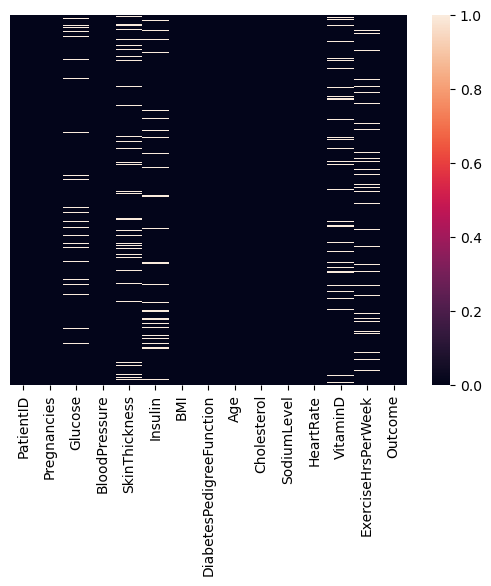

In [3]:
sns.heatmap(df.isnull(),yticklabels=False)

In [4]:
df.isnull().sum()

PatientID                    0
Pregnancies                  0
Glucose                     80
BloodPressure                0
SkinThickness               80
Insulin                     78
BMI                          0
DiabetesPedigreeFunction     0
Age                          0
Cholesterol                  0
SodiumLevel                  0
HeartRate                    0
VitaminD                    81
ExerciseHrsPerWeek          82
Outcome                      0
dtype: int64

In [5]:
row_nulls = df.isnull().sum(axis=1)
print(row_nulls.value_counts().sort_index())

0    673
1    286
2     53
3      3
Name: count, dtype: int64


In [6]:
df.dtypes

PatientID                    object
Pregnancies                   int64
Glucose                      object
BloodPressure                 int64
SkinThickness               float64
Insulin                     float64
BMI                         float64
DiabetesPedigreeFunction    float64
Age                         float64
Cholesterol                   int64
SodiumLevel                 float64
HeartRate                     int64
VitaminD                    float64
ExerciseHrsPerWeek          float64
Outcome                      object
dtype: object

In [8]:
junk = ["O","l","?","#"]
for ch in junk:
    df["Glucose"] = df["Glucose"].str.replace(ch, "", regex=False)
df["Glucose"] = df["Glucose"].apply(lambda x:float(x))
df.dtypes

PatientID                    object
Pregnancies                   int64
Glucose                     float64
BloodPressure                 int64
SkinThickness               float64
Insulin                     float64
BMI                         float64
DiabetesPedigreeFunction    float64
Age                         float64
Cholesterol                   int64
SodiumLevel                 float64
HeartRate                     int64
VitaminD                    float64
ExerciseHrsPerWeek          float64
Outcome                      object
dtype: object

In [9]:
def Outlier_remover(x): 
    q1 = df[x].quantile(0.25)
    q3 = df[x].quantile(0.75)

    iqr = q3 - q1 

    lower = q1 - 1.5*iqr 
    upper = q3 + 1.5*iqr 

    ran = [lower,upper]

    df.loc[ ( (df[x]<lower ) | (df[x]>upper ) ) ,x] = np.nan

In [10]:
num_cols = ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness',
       'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age', 'Cholesterol',
       'SodiumLevel', 'HeartRate', 'VitaminD', 'ExerciseHrsPerWeek']
for col in num_cols: 
    Outlier_remover(col)

In [11]:
df.isnull().sum()

PatientID                     0
Pregnancies                   5
Glucose                     100
BloodPressure                20
SkinThickness                90
Insulin                     129
BMI                          20
DiabetesPedigreeFunction     35
Age                          11
Cholesterol                   0
SodiumLevel                   0
HeartRate                    10
VitaminD                     81
ExerciseHrsPerWeek           82
Outcome                       0
dtype: int64

In [12]:
row_nulls = df.isnull().sum(axis=1)
print(row_nulls.value_counts().sort_index())

0    552
1    357
2     92
3     14
Name: count, dtype: int64


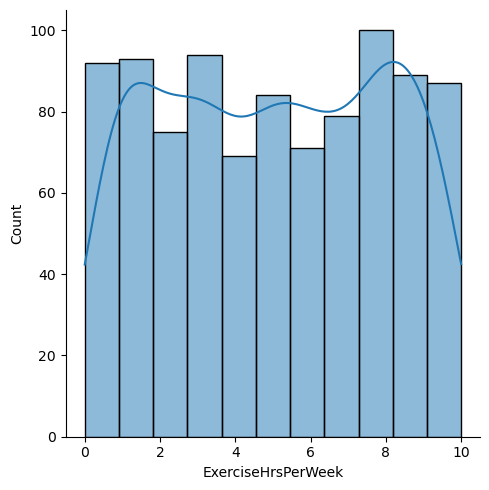

In [13]:
sns.displot(df["ExerciseHrsPerWeek"],kde=True)

In [14]:
df.loc[df["Pregnancies"] < 0, "Pregnancies"] = 0

In [15]:
med = ["Pregnancies","Glucose","BloodPressure","SkinThickness","Insulin","BMI","DiabetesPedigreeFunction",
       "Age","HeartRate","VitaminD","ExerciseHrsPerWeek"]

In [16]:
for col in med:
    df[col] = df[col].fillna(round(df[col].median(),2))

In [17]:
df.isnull().sum()

PatientID                   0
Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Cholesterol                 0
SodiumLevel                 0
HeartRate                   0
VitaminD                    0
ExerciseHrsPerWeek          0
Outcome                     0
dtype: int64

In [18]:
df["Outcome"].unique()

array(['0', '1', 'Yes', '1.0', '0.0', 'No', 'TRUE', 'FALSE'], dtype=object)

In [19]:
y = ["1","1.0","TRUE"]
n = ["0","0.0","FALSE"]
df["Outcome"] = df["Outcome"].replace(y,"Yes").replace(n,"No")

In [20]:
df["Outcome"].unique()

array(['No', 'Yes'], dtype=object)

In [21]:
# Remove duplicate rows based on PatientID
df = df.drop_duplicates(subset='PatientID', keep='first')

print(f"Rows after removing duplicates: {len(df)}")  # Should be 1000

# Save cleanly (index=False prevents the Unnamed: 0 issue)
df.to_csv('Diabetes_cleaned.csv', index=False)

Rows after removing duplicates: 1000


In [22]:
df.to_csv("Diabetes_cleaned.csv")

In [23]:
from sklearn.preprocessing import MinMaxScaler , StandardScaler

col_scale = ["Pregnancies","Glucose","BloodPressure","SkinThickness","Insulin","BMI","DiabetesPedigreeFunction",
       "Age","HeartRate","VitaminD","ExerciseHrsPerWeek"]


In [24]:
df_norm = df.copy()

scaler_norm = MinMaxScaler()

df_norm[col_scale] = scaler_norm.fit_transform(df[col_scale])

df_norm.to_csv("cleaned_diabetes_normalised.csv")

In [25]:
df_stdz = df.copy() 

scaler_stdz = StandardScaler() 

df_stdz[col_scale] = scaler_stdz.fit_transform(df[col_scale])

df_stdz.to_csv("cleaned_diabetes_standardized.csv")

## #1	A medical researcher wants to determine whether higher BMI is associated with higher blood glucose levels. Which chart should be used?


C:\Users\susha\AppData\Local\Temp\ipykernel_23560\288981164.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="Outcome",y="BMI",data=df,palette='Set3')


Text(0.5, 0, 'Outcome (No = Non-Diabetic, Yes = Diabetic)')

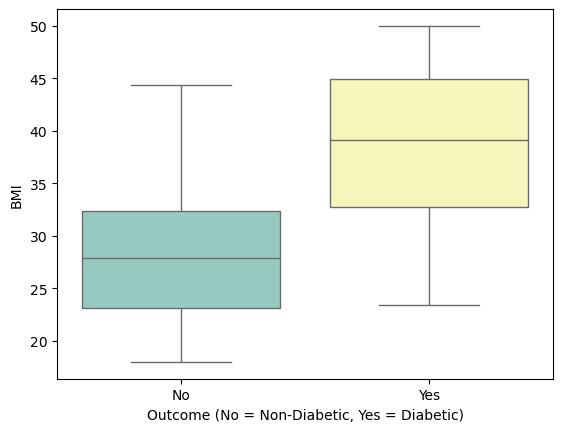

In [28]:
sns.boxplot(x="Outcome",y="BMI",data=df,palette='Set3')
plt.xlabel('Outcome (No = Non-Diabetic, Yes = Diabetic)')


## 3 Doctors want to track average blood glucose levels month by month. Which chart best shows this trend?

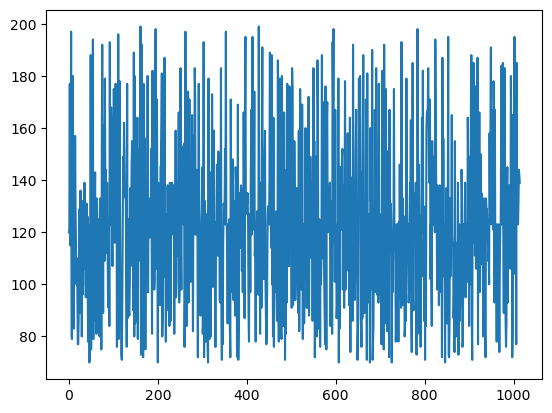

In [29]:
plt.plot(df["Glucose"])

(array([111., 114., 107., 106., 247., 111.,  56.,  55.,  57.,  36.]),
 array([ 70. ,  82.9,  95.8, 108.7, 121.6, 134.5, 147.4, 160.3, 173.2,
        186.1, 199. ]),
 <BarContainer object of 10 artists>)

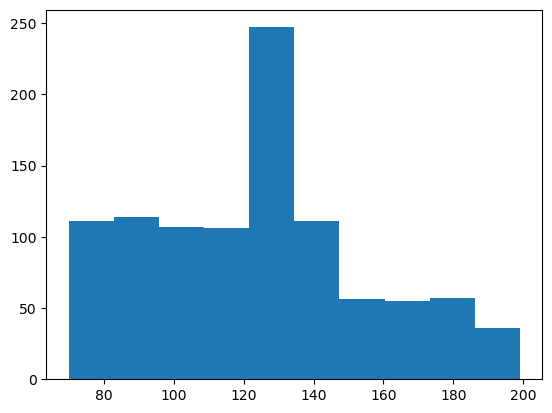

In [32]:
plt.hist(df["Glucose"])

## 4.Researchers suspect a few diabetic patients have extremely high insulin levels compared to others. Which chart reveals such outliers?

<Axes: xlabel='Outcome', ylabel='Insulin'>

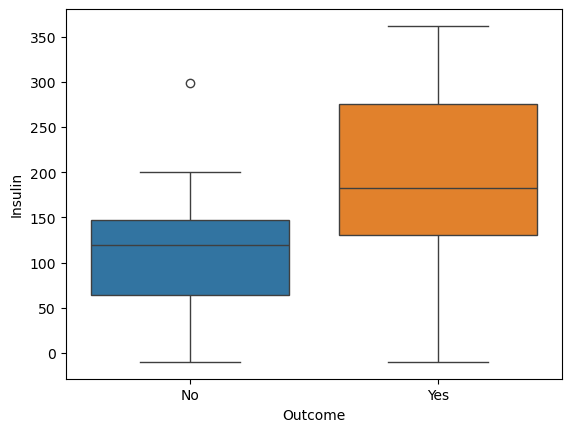

In [37]:
sns.boxplot(x="Outcome",y="Insulin",hue="Outcome",data=df)

## 5. The clinic wants to understand how blood glucose values are distributed among patients. Which chart should be used?


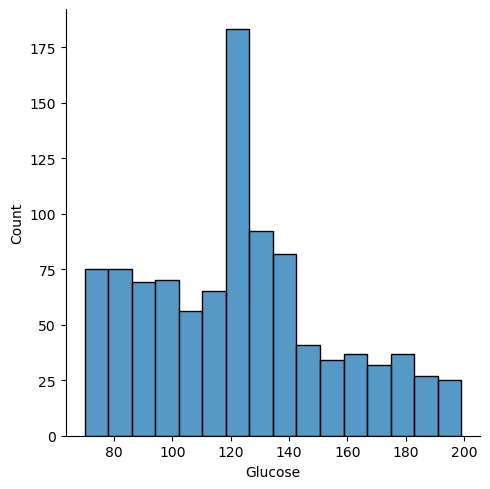

In [38]:
sns.displot(df["Glucose"])

## 6. A physician wants to compare average BMI between diabetic and non-diabetic groups. Which chart is appropriate?